Number of total bubbles = 32


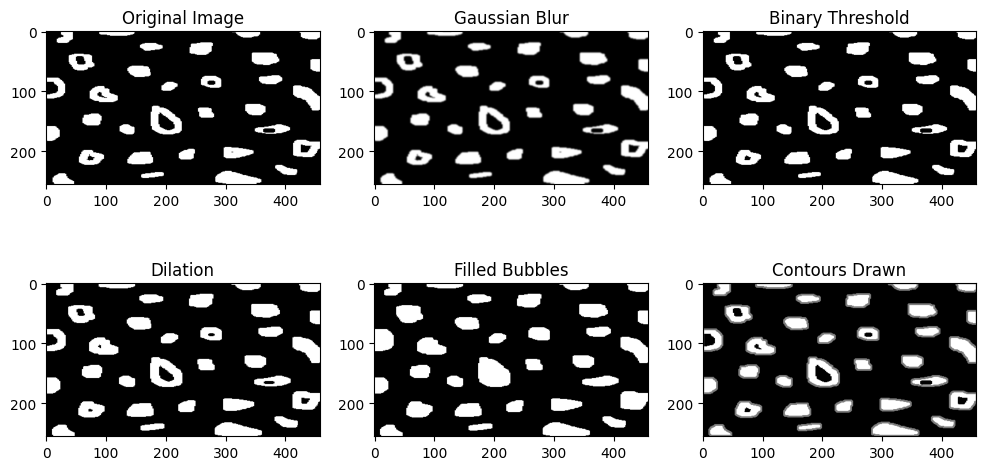

In [14]:
# This section is for counting the number of total bubbles.

# Import libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Read the original image
img_original = cv.imread('images/result_bubbles_original.jpeg', 0)

# Create a copy of original image
img = img_original.copy()

# Get image height and width
h, w = img.shape

# Apply Gaussian blur to reduce noise and smooth the image
blur = cv.GaussianBlur(img, (5,5), 1)

# Convert the image to binary using a fixed threshold value
_,thresh = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)

# Create a 3x3 kernel for dilation
kernel = np.ones((3, 3), np.uint8)

# Apply dilation to fill the hollow regions inside the bubbles
dilation = cv.dilate(thresh, kernel, iterations=1)

# Make a copy of the dilated image because floodFill modifies the image directly
ff = dilation.copy()

# Note: the mask size must be 2 pixels larger than the image in both dimensions
mask = np.zeros((h + 2, w + 2), np.uint8)

# Flood fill the background starting from the top-left corner (0, 0)
# This fills the outer black background with white
cv.floodFill(ff, mask, (0, 0), 255)

# Invert the flood-filled image
# After inversion, the holes inside the bubbles become white
ff_inv = cv.bitwise_not(ff)

# Combine the dilated image with the inverted flood-filled image
# This fills the holes inside the bubbles
filled = dilation | ff_inv

# Find external contours in the dilated image
contours, _ = cv.findContours(filled, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

# Create a copy of the threshold image
img2 =thresh.copy()

# Draw each contour on the copied image
for c in contours:
    cv.drawContours(img2, [c], -1, 125, 2)

# Print the total number of detected bubbles (contours)
print(f"Number of total bubbles = {len(contours)}")

# Display images
plt.figure(figsize=[12, 6])
plt.subplot(231); plt.imshow(img_original, cmap='gray'); plt.title('Original Image')
plt.subplot(232); plt.imshow(blur, cmap='gray'); plt.title('Gaussian Blur')
plt.subplot(233); plt.imshow(thresh, cmap='gray'); plt.title('Binary Threshold')
plt.subplot(234); plt.imshow(dilation, cmap='gray'); plt.title('Dilation')
plt.subplot(235); plt.imshow(filled, cmap='gray'); plt.title('Filled Bubbles')
plt.subplot(236); plt.imshow(img2, cmap='gray'); plt.title('Contours Drawn');

In [15]:
# This section is for counting the  number of empty bubbles.

# List to store the center coordinates of each contour
centers = []

# Iterate through each contour to calculate its geometric center using image moments
for contour in contours:
    M = cv.moments(contour)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    centers.append((cx, cy))

# List to store centers of empty bubbles 
empty_bubbles = []

# Examine each center point to determine if its corresponding bubble is empty or filled
for center in centers:
    x, y = center[0], center[1]
    is_empty = False

    # Define a 4x4 pixel search region around the center point
    for dx in range(-2, 2):
        for dy in range(-2, 2):
            if img[y + dy, x + dx] == 0:
                is_empty = True
                
    if is_empty:
        empty_bubbles.append(center)
    
# Print Numbers
print(f"Number of empty bubbles = {len(empty_bubbles)}")
print(f"Number of filled bubbles = {len(contours) - len(empty_bubbles)}")

Number of empty bubbles = 8
Number of filled bubbles = 24
